In [3]:

from huggingface_hub import notebook_login

notebook_login()

In [ ]:
%pip install -q -U torch transformers accelerate huggingface_hub psutil
# https://huggingface.co/HuggingFaceTB/SmolLM2-360M-Instruct

from transformers import AutoTokenizer
import torch

MODEL_ID = "HuggingFaceTB/SmolLM2-360M-Instruct"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DTYPE = (
    torch.float16
    if DEVICE == "cuda"
    else torch.float32
)

print("Device :", DEVICE)
print("Dtype  :", DTYPE)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID,
    use_fast=True
)
print("Tokenizer chargé.")


Device : cpu
Dtype  : torch.float32
Tokenizer chargé.


In [ ]:
# https://docs.pytorch.org/tutorials/intermediate/pruning_tutorial.html

import torch.nn.utils.prune as prune
import copy
from transformers import AutoModelForCausalLM

model_base = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=DTYPE,
).to(DEVICE)

model_pruned = copy.deepcopy(model_base)

for module in model_pruned.modules():
    if isinstance(module, torch.nn.Linear):
        prune.l1_unstructured(module, name="weight", amount=0.20)

for module in model_pruned.modules():
    if isinstance(module, torch.nn.Linear):
        prune.remove(module, "weight")



[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

In [5]:
# Mesurer perplexité et accuracy du prochain token
import math
import torch.nn.functional as F
from datasets import load_dataset

dataset = load_dataset(
    "Salesforce/wikitext",
    "wikitext-2-raw-v1",
    split="validation",
)

texts = [t for t in dataset["text"] if t.strip()][:500]
encoded = tokenizer("\n\n".join(texts), return_tensors="pt")["input_ids"][0]

context_length = getattr(model_base.config, "max_position_embeddings", 1024)
seq_len = min(context_length, 512)

def quality_metrics(model, input_ids, seq_len):
    model.eval()
    total_nll = 0.0
    total_tokens = 0
    correct = 0

    with torch.inference_mode():
        for start in range(0, input_ids.numel() - 1, seq_len):
            chunk = input_ids[start : start + seq_len + 1]
            if chunk.numel() < 2:
                continue

            x = chunk[:-1].unsqueeze(0).to(DEVICE)
            y = chunk[1:].unsqueeze(0).to(DEVICE)

            logits = model(input_ids=x).logits
            logits = logits[:, :y.shape[1], :]

            total_nll += F.cross_entropy(
                logits.reshape(-1, logits.size(-1)),
                y.reshape(-1),
                reduction="sum",
            ).item()

            predictions = logits.argmax(dim=-1)
            correct += (predictions == y).sum().item()
            total_tokens += y.numel()

    mean_nll = total_nll / total_tokens
    return {
        "perplexity": math.exp(mean_nll),
        "next_token_accuracy": correct / total_tokens,
    }

quality_base = quality_metrics(model_base, encoded, seq_len)
quality_pruned = quality_metrics(model_pruned, encoded, seq_len)

print("Base :", quality_base)
print("Pruné:", quality_pruned)



[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (47472 > 8192). Running this sequence through the model will result in indexing errors


Base : {'perplexity': 15.60452616464991, 'next_token_accuracy': 0.4665795959638516}
Pruné: {'perplexity': 17.79200446646923, 'next_token_accuracy': 0.44467148364264497}


In [ ]:
# Mesurer latence, tokens et mémoire
import numpy as np
import time

prompt = "Être ou ne pas être, telle est la question ?"
inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)

MAX_NEW_TOKENS = 64
WARMUP = 3
REPEATS = 30

def benchmark_generation(model, inputs, max_new_tokens=MAX_NEW_TOKENS):
    model.eval()

    def synchronize():
        if torch.cuda.is_available() and str(DEVICE).startswith("cuda"):
            torch.cuda.synchronize()

    with torch.inference_mode():
        for _ in range(WARMUP):
            _ = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                use_cache=True,
            )
    synchronize()

    if torch.cuda.is_available() and str(DEVICE).startswith("cuda"):
        torch.cuda.reset_peak_memory_stats()
        allocated_before = torch.cuda.memory_allocated()

    latencies = []
    generated_counts = []

    with torch.inference_mode():
        for _ in range(REPEATS):
            synchronize()
            t0 = time.perf_counter()

            output = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                use_cache=True,
            )

            synchronize()
            latencies.append(time.perf_counter() - t0)
            generated_counts.append(output.shape[1] - inputs["input_ids"].shape[1])

    latencies = np.array(latencies)
    generated_counts = np.array(generated_counts)

    result = {
        "latency_p50_s": np.percentile(latencies, 50),
        "latency_p95_s": np.percentile(latencies, 95),
        "tokens_per_s": generated_counts.sum() / latencies.sum(),
    }

    if torch.cuda.is_available() and str(DEVICE).startswith("cuda"):
        result["peak_vram_mb"] = torch.cuda.max_memory_allocated() / 1024**2
        result["vram_increase_mb"] = (
            torch.cuda.max_memory_allocated() - allocated_before
        ) / 1024**2
    else:
        result["peak_vram_mb"] = np.nan
        result["vram_increase_mb"] = np.nan

    return result

perf_base = benchmark_generation(model_base, inputs)
perf_pruned = benchmark_generation(model_pruned, inputs)

print("Base :", perf_base)
print("Pruné:", perf_pruned)



Base : {'latency_p50_s': np.float64(11.038022778499908), 'latency_p95_s': np.float64(11.977023262250214), 'tokens_per_s': np.float64(5.74909987805785), 'peak_vram_mb': nan, 'vram_increase_mb': nan}
Pruné: {'latency_p50_s': np.float64(12.17656480650021), 'latency_p95_s': np.float64(13.950433577600142), 'tokens_per_s': np.float64(5.224447366837882), 'peak_vram_mb': nan, 'vram_increase_mb': nan}


In [10]:
import os
import psutil

process = psutil.Process(os.getpid())

def measure_memory_mb():
    ram_mb = process.memory_info().rss / 1024**2

    if torch.cuda.is_available():
        torch.cuda.synchronize()
        gpu_allocated_mb = torch.cuda.memory_allocated() / 1024**2
        gpu_reserved_mb = torch.cuda.memory_reserved() / 1024**2
        gpu_peak_mb = torch.cuda.max_memory_allocated() / 1024**2
    else:
        gpu_allocated_mb = float("nan")
        gpu_reserved_mb = float("nan")
        gpu_peak_mb = float("nan")

    return {
        "ram_process_mb": ram_mb,
        "gpu_allocated_mb": gpu_allocated_mb,
        "gpu_reserved_mb": gpu_reserved_mb,
        "gpu_peak_mb": gpu_peak_mb,
    }



In [9]:
# Comparer plusieurs taux d’élagage et tracer coût/performance
import pandas as pd

def make_pruned_copy(base_model, amount):
    model = copy.deepcopy(base_model)

    for module in model.modules():
        if isinstance(module, torch.nn.Linear):
            prune.l1_unstructured(module, name="weight", amount=amount)

    for module in model.modules():
        if isinstance(module, torch.nn.Linear) and hasattr(module, "weight_orig"):
            prune.remove(module, "weight")

    return model.eval()

rows = []

for amount in [0.0, 0.10, 0.20, 0.30, 0.40]:
    candidate = model_base if amount == 0 else make_pruned_copy(model_base, amount)

    q = quality_metrics(candidate, encoded, seq_len)
    p = benchmark_generation(candidate, inputs)
    m = measure_memory_mb()

    rows.append({
        "pruning": amount,
        **q,
        **p,
        **m,
    })

    if amount != 0:
        del candidate
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

results = pd.DataFrame(rows)
results


,pruning,perplexity,next_token_accuracy,latency_p50_s,latency_p95_s,tokens_per_s,peak_vram_mb,vram_increase_mb,ram_process_mb,gpu_allocated_mb,gpu_reserved_mb,gpu_peak_mb
0,0.0,15.604526,0.466580,10.660082,11.829719,5.959763,NaN,NaN,5150.828125,NaN,NaN,NaN
1,0.1,16.000002,0.463188,10.741465,11.325574,5.919172,NaN,NaN,6838.722656,NaN,NaN,NaN
2,0.2,17.792004,0.444671,12.209799,13.775406,5.200117,NaN,NaN,6440.992188,NaN,NaN,NaN
3,0.3,33.435128,0.367804,12.064314,12.950094,5.252693,NaN,NaN,6067.343750,NaN,NaN,NaN
4,0.4,68.116447,0.275410,1.030321,1.085278,4.851873,NaN,NaN,5888.664062,NaN,NaN,NaN


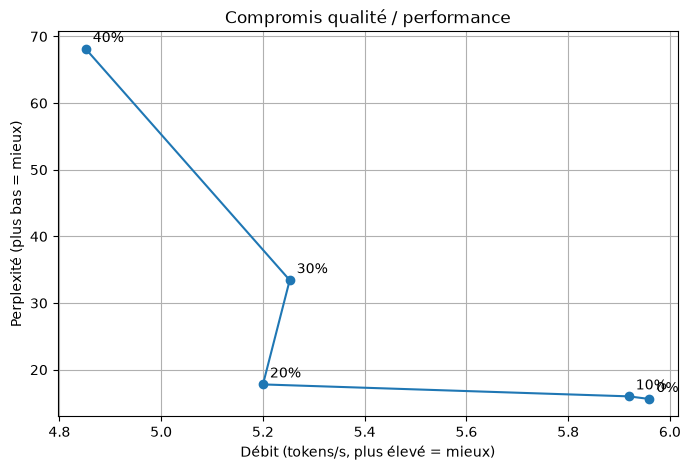

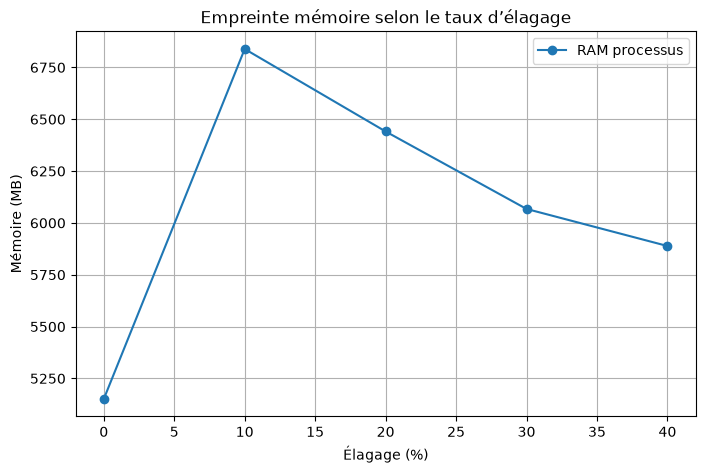

CSV enregistré : /home/dupp/GIT/intelligence-artificielle/2_Efficacité et compression/pruning_results/comparaison.csv
Graphique qualité/performance : /home/dupp/GIT/intelligence-artificielle/2_Efficacité et compression/pruning_results/compromis_qualite_performance.png
Graphique mémoire : /home/dupp/GIT/intelligence-artificielle/2_Efficacité et compression/pruning_results/empreinte_memoire.png


In [11]:
from pathlib import Path
import matplotlib.pyplot as plt

output_dir = Path("pruning_results")
output_dir.mkdir(parents=True, exist_ok=True)

csv_path = output_dir / "comparaison.csv"
results.to_csv(csv_path, index=False, encoding="utf-8-sig")

# Graphique 1
fig1, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(results["tokens_per_s"], results["perplexity"], marker="o")

for _, row in results.iterrows():
    ax1.annotate(
        f'{row["pruning"]:.0%}',
        (row["tokens_per_s"], row["perplexity"]),
        xytext=(5, 5),
        textcoords="offset points",
    )

ax1.set_xlabel("Débit (tokens/s, plus élevé = mieux)")
ax1.set_ylabel("Perplexité (plus bas = mieux)")
ax1.set_title("Compromis qualité / performance")
ax1.grid(True)

quality_path = output_dir / "compromis_qualite_performance.png"
fig1.savefig(quality_path, dpi=300, bbox_inches="tight")

# Graphique 2
fig2, ax2 = plt.subplots(figsize=(8, 5))

x = results["pruning"] * 100

if "ram_process_mb" in results.columns:
    ax2.plot(x, results["ram_process_mb"], marker="o", label="RAM processus")

if "gpu_peak_mb" in results.columns and results["gpu_peak_mb"].notna().any():
    ax2.plot(x, results["gpu_peak_mb"], marker="s", label="Pic mémoire GPU")

ax2.set_xlabel("Élagage (%)")
ax2.set_ylabel("Mémoire (MB)")
ax2.set_title("Empreinte mémoire selon le taux d’élagage")
ax2.grid(True)
ax2.legend()

memory_path = output_dir / "empreinte_memoire.png"
fig2.savefig(memory_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"CSV enregistré : {csv_path.resolve()}")
print(f"Graphique qualité/performance : {quality_path.resolve()}")
print(f"Graphique mémoire : {memory_path.resolve()}")
